# Шугаман давхрага

Сэргээн санах CS308. Дараах шугаман давхрагын объектыг гүйцээн бичнэ үү.

In [1]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import cupy as np   

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

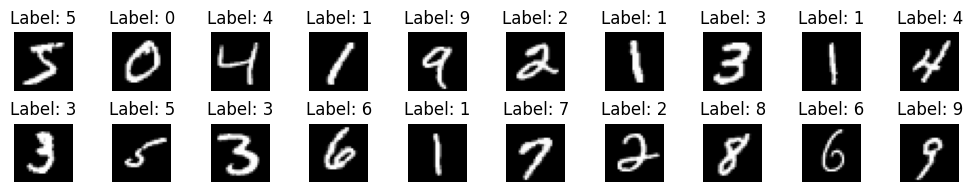

In [2]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

def show_samples(dataset, n= 20):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n//2, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')   
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)


In [3]:
import numpy as np

fac = 5

class Linear_Layer:
    def __init__(self, in_dim, out_dim, alpha = 0.01, Theta = None, bias = None):
        self.alpha = alpha
        if Theta == None:
            self.Theta = np.random.randn(in_dim, out_dim)/fac
        else:
            self.Theta = Theta
        if bias == None:
            self.bias = np.random.randn(out_dim)/fac
        else:
            self.bias = bias
    def forward_pass(self, X):
        self.X = X
        # self.z = None
        self.z = np.matmul(X, self.Theta) + self.bias
        return self.z
    def backprop(self, grad_previous):
        t= self.X.shape[0]
        # self.grad = None
        self.grad = np.matmul(self.X.T, grad_previous) / t
        # self.grad_bias = None
        self.grad_bias = np.sum(grad_previous, axis=0) / t
        self.grad_a = np.matmul(grad_previous, self.Theta.transpose())
        return self.grad_a
    def applying_sgd(self):
            self.Theta = self.Theta - (self.alpha*self.grad)
            self.bias = self.bias - (self.alpha*self.grad_bias)

In [ ]:
class ConvLayer:
    def __init__(self, filter_dim=3, stride=1, pad=1, alpha=0.01, num_kernels=8, in_channels=None):
        self.filter_dim = filter_dim
        self.stride = stride
        self.num_kernels = num_kernels
        self.in_channels = in_channels  
        self.pad = pad
        self.alpha = alpha

    def _init_weights(self, in_ch):
        fac = 5
        self.filter = np.random.randn(self.num_kernels, in_ch, self.filter_dim, self.filter_dim) / fac
        self.bias = np.random.randn(self.num_kernels) / fac

    def _convolve_single(self, X, fil, dimen_x, dimen_y):
        z = np.zeros((dimen_x, dimen_y))
        in_ch, p, t = X.shape
        for i in range(dimen_x):
            for ii in range(dimen_y):
                x0 = i * self.stride
                y0 = ii * self.stride
                patch = X[:, x0:x0 + self.filter_dim, y0:y0 + self.filter_dim]
                z[i, ii] = np.sum(patch * fil)
        return z

    def forward_pass(self, X):
        if X.ndim == 3:
            X = X[:, np.newaxis, :, :]
        self.X = X
        N, in_ch, p, t = X.shape
        if not hasattr(self, 'filter') or self.filter is None:
            if self.in_channels is None:
                self.in_channels = in_ch
            self._init_weights(self.in_channels)

        dimen_x = int((p - self.filter_dim) / self.stride) + 1
        dimen_y = int((t - self.filter_dim) / self.stride) + 1
        self.z = np.zeros((N, self.num_kernels, dimen_x, dimen_y))

        for n in range(N):
            for k in range(self.num_kernels):
                self.z[n, k] = self._convolve_single(
                    self.X[n], self.filter[k], dimen_x, dimen_y
                ) + self.bias[k]
        return self.z

    def backprop(self, grad_z):
        N, K, out_h, out_w = grad_z.shape
        _, in_ch, in_h, in_w = self.X.shape
        F = self.filter_dim

        self.grads = np.zeros_like(self.X)
        for n in range(N):
            for oi in range(out_h):
                for oj in range(out_w):
                    for fi in range(F):
                        for fj in range(F):
                            i, j = oi * self.stride + fi, oj * self.stride + fj
                            if 0 <= i < in_h and 0 <= j < in_w:
                                for c in range(in_ch):
                                    for k in range(K):
                                        self.grads[n, c, i, j] += grad_z[n, k, oi, oj] * self.filter[k, c, fi, fj]

        self.grad_filter = np.zeros_like(self.filter)
        for k in range(K):
            for c in range(in_ch):
                for fi in range(F):
                    for fj in range(F):
                        self.grad_filter[k, c, fi, fj] = np.sum(
                            grad_z[:, k, :, :] * self.X[:, c, fi:fi+out_h*self.stride:self.stride, fj:fj+out_w*self.stride:self.stride]
                        )
        self.grad_filter = self.grad_filter / (N * out_h * out_w)
        self.grad_bias = np.sum(grad_z, axis=(0, 2, 3)) / (N * out_h * out_w)
        return self.grads

    def applying_sgd(self):
        self.filter = self.filter - self.alpha * self.grad_filter
        self.bias = self.bias - self.alpha * self.grad_bias

    def change_alpha(self):
        self.alpha = self.alpha / 10


## Даалгавар

1. Кодыг гүйцээн ажиллуулах
2. Олон кернэл дээр ажилладаг болгох

In [5]:
class Pooling:
    def __init__(self, pool_dim=2, stride=2):
        self.pool_dim = pool_dim
        self.stride = stride

    def forward_pass(self, data):
        if data.ndim == 3:
            q, p, t = data.shape
            n_channels = 1
            data = data[:, np.newaxis, :, :]
        else:
            q, n_channels, p, t = data.shape
        z_x = int((p - self.pool_dim) / self.stride) + 1
        z_y = int((t - self.pool_dim) / self.stride) + 1
        after_pool = np.zeros((q, n_channels, z_x, z_y))
        for batch in range(q):
            for ch in range(n_channels):
                count = 0
                for i in range(0, p, self.stride):
                    for j in range(0, t, self.stride):
                        if (i + self.pool_dim <= p) and (j + self.pool_dim <= t):
                            temp = data[batch, ch, i:i + self.pool_dim, j:j + self.pool_dim]
                            after_pool[batch, ch, count // z_y, count % z_y] = np.max(temp)
                            count += 1
        return after_pool

    def backprop(self, pooled):
        if pooled.ndim == 3:
            a, b, c = pooled.shape
            pooled = pooled[:, np.newaxis, :, :]
        a, n_ch, b, c = pooled.shape
        cheated = np.zeros((a, n_ch, 2 * b, 2 * c))
        for batch in range(a):
            for ch in range(n_ch):
                count = 0
                for i in range(0, 2 * b, self.stride):
                    for j in range(0, 2 * c, self.stride):
                        cheated[batch, ch, i:i + self.stride, j:j + self.stride] = pooled[batch, ch, count // c, count % c]
                        count += 1
        return cheated

    def applying_sgd(self):
        pass


In [6]:
class softmax:
    def __init__(self):
        pass
    def expansion(self, t):
        (a,) = t.shape
        Y = np.zeros((a,10))
        for i in range(0,a):
            Y[i,t[i]] = 1
        return Y
    def forward_pass(self, z):
        self.z =  z

        # (p,t) = self.z.shape
        # self.a = np.zeros((p,t))
        # for i in range(0,p):
        #     for ii in range(0,t):
        #         self.a[i,ii] = None #

        z_shift = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shift)
        self.a = exp_z / np.sum(exp_z, axis=1, keepdims=True)
        return self.a
        
    def backprop(self, Y):
        y = self.expansion(Y)
        self.grad = (self.a - y)
        return self.grad
    def applying_sgd(self):
        pass

In [ ]:
class relu:
    def __init__(self):
        pass

    def forward_pass(self, z):
        self.z = z
        return np.maximum(0, z)

    def backprop(self, grad_previous):
        return grad_previous * (self.z > 0)

    def applying_sgd(self):
        pass

class padding():
    def __init__(self, pad=1):
        self.pad = pad

    def forward_pass(self, data):
        p = self.pad
        if data.ndim == 3:
            return np.pad(data, ((0, 0), (p, p), (p, p)), 'constant', constant_values=0)
        elif data.ndim == 4:
            return np.pad(data, ((0, 0), (0, 0), (p, p), (p, p)), 'constant', constant_values=0)
        else:
            raise ValueError(f"padding: expected 3D or 4D input, got shape {data.shape}")

    def backprop(self, y):
        p = self.pad
        if y.ndim == 3:
            return y[:, p:(y.shape[1] - p), p:(y.shape[2] - p)]
        elif y.ndim == 4:
            return y[:, :, p:(y.shape[2] - p), p:(y.shape[3] - p)]
        else:
            raise ValueError(f"padding.backprop: expected 3D or 4D grad, got shape {y.shape}")

    def applying_sgd(self):
        pass


class reshaping:
    def __init__(self):
        pass

    def forward_pass(self, a):
        self.shape_a = a.shape
        return a.reshape(a.shape[0], -1)

    def backprop(self, q):
        return q.reshape(self.shape_a)

    def applying_sgd(self):
        pass

class cross_entropy:
    def __init__(self):
        pass
    def expansion(self, t):
        (a,) = t.shape
        Y = np.zeros((a,10))
        for i in range(0,a):
            Y[i,t[i]] = 1
        return Y
    def loss(self, A, Y):
        eps = 1e-8
        A = np.clip(A, eps, 1 - eps)

        exp_Y = self.expansion(Y)
        (u,i) = A.shape
        loss_matrix = np.zeros((u,i))
        for j in range(u):
            for jj in range(i):
                if exp_Y[j,jj] == 0:
                    loss_matrix[j,jj] = np.log(1 - A[j,jj])
                else:
                    loss_matrix[j,jj] = np.log(A[j,jj])
        return ((-(loss_matrix.sum()))/u)

class accuracy:
    def __init__(self):
        pass
    def value(self, out, Y):
        self.out = np.argmax(out, axis=1)
        p = self.out.shape[0]
        total = 0
        for i in range(p):
            if Y[i]==self.out[i]:
                total += 1
        return total/p

class ConvNet:
    def __init__(self, Network):
        self.Network = Network
    def forward_pass(self, X):
        n = X
        for i in self.Network:
            n = i.forward_pass(n)
            # print(n.shape) #
        return n
    def backprop(self, Y):
        m = Y
        count = 1
        for i in (reversed(self.Network)):
            m = i.backprop(m)
    def applying_sgd(self):
        for i in self.Network:
            i.applying_sgd()

In [ ]:
Xtr = train_dataset.data.numpy().astype(np.float32) / 255.0
Ytr = train_dataset.targets.numpy().astype(np.int64)
Xte = test_dataset.data.numpy().astype(np.float32) / 255.0
Yte = test_dataset.targets.numpy().astype(np.int64)

X_training = Xtr[:1000, :, :]
Y_training = Ytr[:1000]

al = 0.3
stopper = 99.0

# 8 -> 8 -> 16 channels. After conv/pool/conv/pool/conv with 28x28 input, output is (N,16,5,5).
complete_NN = ConvNet([
    padding(),
    ConvLayer(num_kernels=8, alpha=al),
    Pooling(),
    relu(),

    padding(),
    ConvLayer(num_kernels=8, in_channels=8, alpha=al),
    Pooling(),
    relu(),

    ConvLayer(num_kernels=16, in_channels=8, alpha=al),
    relu(),

    reshaping(),
    Linear_Layer(16 * 5 * 5, 24, alpha=al),
    relu(),
    Linear_Layer(24, 10, alpha=al),
    softmax(),
])

CE = cross_entropy()
acc = accuracy()

_ = complete_NN.forward_pass(X_training[:2])

epochs = 30
broke = 0
batch_size = 128
n = len(X_training)

for i in range(epochs):
    for bi, k in enumerate(range(0, n, batch_size), start=1):
        xb = X_training[k:k + batch_size]
        yb = Y_training[k:k + batch_size]

        out = complete_NN.forward_pass(xb)
        print(
            "epoch:{}\tbatch:{}\tloss:\t{}".format(i + 1, bi, CE.loss(out, yb)),
            end="\t",
        )
        accur = acc.value(out, yb) * 100
        print("accuracy: {}".format(accur))

        if accur >= stopper:
            broke = 1
            break

        complete_NN.backprop(yb)
        complete_NN.applying_sgd()

    if broke == 1:
        break

out = complete_NN.forward_pass(X_training)
print("The final loss is {}".format(CE.loss(out, Y_training)))
print("The final accuracy on train set is {}".format(acc.value(out, Y_training) * 100))

# Optional test:
# Xtest = Xte
# out_1 = complete_NN.forward_pass(Xtest)
# print("The accuracy on test set is {}".format(acc.value(out_1, Yte) * 100))


epoch:1	batch:1	loss:	3.8585145857190817	accuracy: 11.71875
epoch:1	batch:2	loss:	3.2527788705427914	accuracy: 14.0625
epoch:1	batch:3	loss:	3.1609043320846233	accuracy: 17.96875
epoch:1	batch:4	loss:	3.0955900858306538	accuracy: 24.21875
epoch:1	batch:5	loss:	3.1210801326804902	accuracy: 20.3125
epoch:1	batch:6	loss:	3.040761162016935	accuracy: 24.21875
epoch:1	batch:7	loss:	3.025003648699001	accuracy: 28.90625
epoch:1	batch:8	loss:	2.9470841629781117	accuracy: 32.69230769230769
epoch:2	batch:1	loss:	2.833240983679125	accuracy: 42.1875
epoch:2	batch:2	loss:	2.828916927654925	accuracy: 36.71875
epoch:2	batch:3	loss:	2.654905522414393	accuracy: 45.3125
epoch:2	batch:4	loss:	2.5933585188125288	accuracy: 50.0
epoch:2	batch:5	loss:	2.629170749313909	accuracy: 49.21875
epoch:2	batch:6	loss:	2.54487656101643	accuracy: 46.09375
epoch:2	batch:7	loss:	2.502704757381223	accuracy: 50.78125
epoch:2	batch:8	loss:	2.3938649275385893	accuracy: 48.07692307692308
epoch:3	batch:1	loss:	2.443683275503437

In [8]:
# 5) Илүү гүн (deeper) загвар: Conv8 -> Conv16 -> Conv32 -> Conv32 -> FC64 -> FC10
# Shape check (MNIST 28x28):
# pad -> conv -> pool : 28x28 -> 14x14
# pad -> conv -> pool : 14x14 -> 7x7
# pad -> conv (keep 7x7)
# conv (no pad) -> 5x5


Xtr = train_dataset.data.numpy().astype(np.float32) / 255.0
Ytr = train_dataset.targets.numpy().astype(np.int64)
Xte = test_dataset.data.numpy().astype(np.float32) / 255.0
Yte = test_dataset.targets.numpy().astype(np.int64)

# Use a subset for faster experiments
X_all = Xtr[:1000, :, :]
Y_all = Ytr[:1000]


val_frac = 0.2
rng = np.random.RandomState(42)
perm = rng.permutation(len(X_all))
val_size = int(len(X_all) * val_frac)
val_idx = perm[:val_size]
train_idx = perm[val_size:]

X_train = X_all[train_idx]
Y_train = Y_all[train_idx]
X_val = X_all[val_idx]
Y_val = Y_all[val_idx]

al = 0.3
stopper = 99.0  

complete_NN = ConvNet([
    padding(),
    ConvLayer(num_kernels=8, alpha=al),
    Pooling(),
    relu(),

    padding(),
    ConvLayer(num_kernels=8, in_channels=8, alpha=al),
    Pooling(),
    relu(),

    ConvLayer(num_kernels=16, in_channels=8, alpha=al),
    relu(),

    reshaping(),
    Linear_Layer(16 * 5 * 5, 24, alpha=al),
    relu(),
    Linear_Layer(24, 10, alpha=al),
    softmax(),
])

CE = cross_entropy()
acc = accuracy()

def eval_accuracy(model, X, Y, bs=256):
    correct = 0
    total = 0
    for i in range(0, len(X), bs):
        xb = X[i:i+bs]
        yb = Y[i:i+bs]
        out = model.forward_pass(xb)
        pred = np.argmax(out, axis=1)
        correct += np.sum(pred == yb)
        total += len(yb)
    return correct / total

# Initialize weights/shapes
_ = complete_NN.forward_pass(X_train[:2])

epochs = 30
batch_size = 128
n = len(X_train)

for ep in range(epochs):
    # Shuffle each epoch
    perm = np.random.permutation(n)
    Xs = X_train[perm]
    Ys = Y_train[perm]

    for bi, k in enumerate(range(0, n, batch_size), start=1):
        xb = Xs[k:k + batch_size]
        yb = Ys[k:k + batch_size]

        out = complete_NN.forward_pass(xb)
        print(
            "epoch:{}\tbatch:{}\tloss:\t{}".format(ep + 1, bi, CE.loss(out, yb)),
            end="\t",
        )
        batch_acc = acc.value(out, yb) * 100
        print("accuracy: {}".format(batch_acc))

        complete_NN.backprop(yb)
        complete_NN.applying_sgd()

    # Epoch-end metrics
    train_acc = eval_accuracy(complete_NN, X_train, Y_train) * 100
    val_acc = eval_accuracy(complete_NN, X_val, Y_val) * 100
    print(f"End epoch {ep+1}: train acc = {train_acc:.2f}% | val acc = {val_acc:.2f}%")

    if stopper is not None and val_acc >= stopper:
        print(f"Early stopping: val acc reached {val_acc:.2f}%")
        break

out = complete_NN.forward_pass(X_train)
print("The final loss on train set is {}".format(CE.loss(out, Y_train)))
print("The final accuracy on train set is {}".format(acc.value(out, Y_train) * 100))

# Validation + test accuracy
val_acc = eval_accuracy(complete_NN, X_val, Y_val) * 100
print(f"Validation accuracy: {val_acc:.2f}%")

test_acc = eval_accuracy(complete_NN, Xte, Yte) * 100
print(f"Test accuracy: {test_acc:.2f}%")


epoch:1	batch:1	loss:	3.7013604514446667	accuracy: 10.9375
epoch:1	batch:2	loss:	3.311505148937684	accuracy: 7.8125
epoch:1	batch:3	loss:	3.2326898072182955	accuracy: 14.84375
epoch:1	batch:4	loss:	3.217795749115288	accuracy: 23.4375
epoch:1	batch:5	loss:	3.1437919372598477	accuracy: 26.5625
epoch:1	batch:6	loss:	3.190970075721646	accuracy: 17.96875
epoch:1	batch:7	loss:	3.085529763564296	accuracy: 28.125
End epoch 1: train acc = 26.62% | val acc = 23.00%
epoch:2	batch:1	loss:	3.0652750938711013	accuracy: 26.5625
epoch:2	batch:2	loss:	3.106487386154035	accuracy: 25.78125
epoch:2	batch:3	loss:	3.0148237321969575	accuracy: 34.375
epoch:2	batch:4	loss:	3.004161220766344	accuracy: 37.5
epoch:2	batch:5	loss:	2.9121183659703	accuracy: 38.28125
epoch:2	batch:6	loss:	2.9865047851030404	accuracy: 30.46875
epoch:2	batch:7	loss:	3.0264267047905244	accuracy: 25.0
End epoch 2: train acc = 13.63% | val acc = 12.50%
epoch:3	batch:1	loss:	3.070949756288204	accuracy: 13.28125
epoch:3	batch:2	loss:	3.01

In [11]:
import os, pickle

os.makedirs("checkpoints", exist_ok=True)
with open("checkpoints/complete_NN.pkl", "wb") as f:
    pickle.dump(complete_NN, f)

In [12]:
import pickle

with open("checkpoints/complete_NN.pkl", "rb") as f:
    complete_NN = pickle.load(f)

# Даалгавар

3. Загварын суралцаж буй параметрүүдийн тоог гаргах
4. Сургалтын өгөгдлийг бүгдийг ашиглан сургалт хийх
5. Илүү гүн загварт сургалт хийх
6. Үр дүнг илүү сайн гаргах талаарх дүгнэлт хийх

In [9]:
def count_trainable_params(model, verbose=True):
    """Загварын суралцаж буй (trainable) параметрүүдийн тоог гаргана.
    """
    total = 0
    details = []

    for idx, layer in enumerate(model.Network):
        prefix = f"{idx}:{layer.__class__.__name__}"

        Theta = getattr(layer, "Theta", None)
        if Theta is not None and isinstance(Theta, np.ndarray):
            n = int(Theta.size)
            total += n
            details.append((f"{prefix}.Theta", n, Theta.shape))

        bias = getattr(layer, "bias", None)
        if bias is not None and isinstance(bias, np.ndarray):
            n = int(bias.size)
            total += n
            details.append((f"{prefix}.bias", n, bias.shape))

        fil = getattr(layer, "filter", None)
        if fil is not None and isinstance(fil, np.ndarray):
            n = int(fil.size)
            total += n
            details.append((f"{prefix}.filter", n, fil.shape))

    if verbose:
        for name, n, shape in details:
            print(f"{name}: {n} {shape}")
        print("Total trainable params:", total)

    return total


count_trainable_params(complete_NN)

1:ConvLayer.bias: 8 (8,)
1:ConvLayer.filter: 72 (8, 1, 3, 3)
5:ConvLayer.bias: 8 (8,)
5:ConvLayer.filter: 576 (8, 8, 3, 3)
8:ConvLayer.bias: 16 (16,)
8:ConvLayer.filter: 1152 (16, 8, 3, 3)
11:Linear_Layer.Theta: 9600 (400, 24)
11:Linear_Layer.bias: 24 (24,)
13:Linear_Layer.Theta: 240 (24, 10)
13:Linear_Layer.bias: 10 (10,)
Total trainable params: 11706


11706

In [ ]:
# 5) Илүү гүн (deeper) загвар: Conv8 -> Conv16 -> Conv32 -> Conv32 -> FC64 -> FC10
# Shape check (MNIST 28x28):
# pad -> conv -> pool : 28x28 -> 14x14
# pad -> conv -> pool : 14x14 -> 7x7
# pad -> conv (keep 7x7)
# conv (no pad) -> 5x5


Xtr = train_dataset.data.numpy().astype(np.float32) / 255.0
Ytr = train_dataset.targets.numpy().astype(np.int64)
Xte = test_dataset.data.numpy().astype(np.float32) / 255.0
Yte = test_dataset.targets.numpy().astype(np.int64)

# Use a subset for faster experiments
X_all = Xtr[:1000, :, :]
Y_all = Ytr[:1000]


val_frac = 0.2
rng = np.random.RandomState(42)
perm = rng.permutation(len(X_all))
val_size = int(len(X_all) * val_frac)
val_idx = perm[:val_size]
train_idx = perm[val_size:]

X_train = X_all[train_idx]
Y_train = Y_all[train_idx]
X_val = X_all[val_idx]
Y_val = Y_all[val_idx]

al = 0.3
stopper = 99.0  

complete_NN = ConvNet([
    padding(),
    ConvLayer(num_kernels=8, alpha=al),
    Pooling(),
    relu(),

    padding(),
    ConvLayer(num_kernels=16, in_channels=8, alpha=al),
    Pooling(),
    relu(),

    padding(),
    ConvLayer(num_kernels=32, in_channels=16, alpha=al),
    relu(),

    ConvLayer(num_kernels=32, in_channels=32, alpha=al),  # 7x7 -> 5x5
    relu(),

    reshaping(),
    Linear_Layer(32 * 5 * 5, 64, alpha=al),
    relu(),
    Linear_Layer(64, 10, alpha=al),
    softmax(),
])

CE = cross_entropy()
acc = accuracy()

def eval_accuracy(model, X, Y, bs=256):
    correct = 0
    total = 0
    for i in range(0, len(X), bs):
        xb = X[i:i+bs]
        yb = Y[i:i+bs]
        out = model.forward_pass(xb)
        pred = np.argmax(out, axis=1)
        correct += np.sum(pred == yb)
        total += len(yb)
    return correct / total

_ = complete_NN.forward_pass(X_train[:2])

epochs = 30
batch_size = 128
n = len(X_train)

for ep in range(epochs):
    perm = np.random.permutation(n)
    Xs = X_train[perm]
    Ys = Y_train[perm]

    for bi, k in enumerate(range(0, n, batch_size), start=1):
        xb = Xs[k:k + batch_size]
        yb = Ys[k:k + batch_size]

        out = complete_NN.forward_pass(xb)
        print(
            "epoch:{}\tbatch:{}\tloss:\t{}".format(ep + 1, bi, CE.loss(out, yb)),
            end="\t",
        )
        batch_acc = acc.value(out, yb) * 100
        print("accuracy: {}".format(batch_acc))

        complete_NN.backprop(yb)
        complete_NN.applying_sgd()

    train_acc = eval_accuracy(complete_NN, X_train, Y_train) * 100
    val_acc = eval_accuracy(complete_NN, X_val, Y_val) * 100
    print(f"End epoch {ep+1}: train acc = {train_acc:.2f}% | val acc = {val_acc:.2f}%")

    if stopper is not None and val_acc >= stopper:
        print(f"Early stopping: val acc reached {val_acc:.2f}%")
        break

out = complete_NN.forward_pass(X_train)
print("The final loss on train set is {}".format(CE.loss(out, Y_train)))
print("The final accuracy on train set is {}".format(acc.value(out, Y_train) * 100))

val_acc = eval_accuracy(complete_NN, X_val, Y_val) * 100
print(f"Validation accuracy: {val_acc:.2f}%")

test_acc = eval_accuracy(complete_NN, Xte, Yte) * 100
print(f"Test accuracy: {test_acc:.2f}%")


epoch:1	batch:1	loss:	13.836206540535262	accuracy: 12.5
epoch:1	batch:2	loss:	16.178015349858097	accuracy: 17.96875
epoch:1	batch:3	loss:	6.618461647791582	accuracy: 14.0625
epoch:1	batch:4	loss:	3.3678627490774677	accuracy: 14.0625
epoch:1	batch:5	loss:	3.244284552962564	accuracy: 11.71875
epoch:1	batch:6	loss:	3.190578321057707	accuracy: 10.9375
epoch:1	batch:7	loss:	3.191017212405264	accuracy: 18.75
End epoch 1: train acc = 29.75% | val acc = 29.00%
epoch:2	batch:1	loss:	3.0323033572890497	accuracy: 28.125
epoch:2	batch:2	loss:	3.021813239925349	accuracy: 27.34375
epoch:2	batch:3	loss:	2.9768232216742057	accuracy: 33.59375
epoch:2	batch:4	loss:	2.8260124272298923	accuracy: 39.0625
epoch:2	batch:5	loss:	2.800589046353761	accuracy: 39.0625
epoch:2	batch:6	loss:	2.708569272597148	accuracy: 42.1875
epoch:2	batch:7	loss:	2.5665535319431143	accuracy: 53.125
End epoch 2: train acc = 34.00% | val acc = 22.00%
epoch:3	batch:1	loss:	2.693430562578559	accuracy: 41.40625
epoch:3	batch:2	loss:	2

## 6) Үр дүнг сайжруулах 

- Илүү олон жишээ үзэх тусам загварын ерөнхийшүүлэх чадвар нэмэгдэнэ (test accuracy өсөх хандлагатай).
- Загварын параметер, давхарга болон бусад зүйлсийг илүү сайн тохируулах
- Модел-д хэрэглэгдэж буй Convlayer, relu, pooling зэрэг классуудыг илүү сайн алдаагүй бичих